In [1]:
import sys 
import yaml
import h5py 
import torch
from pathlib import Path
import numpy as np 
import argparse
from argparse import ArgumentParser
import itertools 
import src.audio_transforms as at
from src.spatial_attn_lightning import BinauralAttentionModule 
from corpus.swc_mono_test import SWCMonoTestSetH5DatasetForUnitTuning
import pandas as pd 
from tqdm.auto import tqdm
import pickle
import soxr
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity


%matplotlib inline
import matplotlib.pyplot as plt

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [ ]:
dataset = SWCMonoTestSetH5DatasetForUnitTuning(h5_path="/om/user/imgriff/datasets/human_word_rec_SWC_2024/model_eval_stim.h5",
                                    model_sr=44_100,
                               )

dataloader = torch.utils.data.DataLoader(
                            dataset,
                            batch_size=1)

In [3]:
cue, target, same_sex_dist, diff_sex_dist, nat_scene_dist, word_int, target_f0, same_dist_f0, diff_dist_f0 = dataset[0]

In [4]:
config_path = "config/binaural_attn/word_task_v10_main_feature_gain_config.yaml"
ckpt_path =  "attn_cue_models/word_task_v10_main_feature_gain_config/checkpoints/epoch=1-step=24679-v1.ckpt"

In [5]:
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)


In [6]:
model = BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config).eval().cuda()
coch_gram = model.coch_gram.cuda()


Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
Compiling model...


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [7]:
from get_acts_for_sharpening_analysis import AttentionalGains, save_activations, save_metric
    
########################
# Set hooks for backbone
########################
# init array to store activations
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if name in activations:
            activations[name] = torch.cat((activations[name], output.detach()), dim=0)
        else:
            activations[name] = output.detach()
    return hook

if hasattr(model.model, '_orig_mod'):
    modules = {name:module for name, module in model.model._orig_mod.model_dict.named_children()}
    relu_fc = model.model._orig_mod.relufc

else:
    modules = {name:module for name, module in model.model.model_dict.named_children()}
    relu_fc = model.model.relufc

# add relu fc 
modules = {**modules, **{'relufc': relu_fc}}
# register hooks for all layers 
for name, module in modules.items():
    if 'conv' in name:
        module[0].register_forward_hook(get_activation(f"{name}_ln")) # [0] is layer norm 
        module[2].register_forward_hook(get_activation(f"{name}_relu")) # [2] is relu 
    else:
        module.register_forward_hook(get_activation(name)) 

#####################
# Get gain functions
##################### 
## Init gain modules per layer. 
if hasattr(model.model, '_orig_mod'):
    gain_modules = {name:module for name,module in model.model._orig_mod.model_dict.items() if 'attn' in name}
else:
    gain_modules = {name:module for name,module in model.model.model_dict.items() if 'attn' in name}

gain_functions = {} 
for name, module in gain_modules.items():
    gain_functions[name] = AttentionalGains(module.slope, module.bias, module.threshold)

##################################################################
# Set dict mapping layer names to their corresponding gain modules
##################################################################
# want dict that maps conv layer name 'conv_block_<int>_hannpool' to attn module 'attn<int>'
## Map pool layers to gain functions 
pool_layers = [name for name in modules.keys() if "pool" in name]
n_pool_layers = len(pool_layers)
pool_to_gain_map = {}
pool_to_gain_map['cochleagram'] = 'attn0'
for ix, layer in enumerate(pool_layers):
    if str(n_pool_layers - 1) in layer:
        pool_to_gain_map[layer] = 'attnfc'
    else:
        pool_to_gain_map[layer] = f"attn{ix+1}"


In [8]:
snr = 0 
audio_transforms = at.AudioCompose([
                at.AudioToTensor(),
                at.BinauralCombineWithRandomDBSNR(low_snr=snr,    # is 0 dB
                                                high_snr=snr), # is 0 dB 
                at.BinauralRMSNormalizeForegroundAndBackground(rms_level=0.02), # 20 * np.log10(0.02/20e-6) = 60 dB SPL 
        ])
audio_transforms = audio_transforms.cuda()


In [9]:
# model = model.eval().cuda()

# outname = Path("dummy_unit_sharpening_analysis/word_task_v10_main_feature_gain_config_min_test.h5")
# outname.parent.mkdir(parents=True, exist_ok=True)

# n_examples = 10 #len(dataset) # get whole dataset
# time_average = True 



# cue_tgt_ix = 0 

# cue_ixs_to_run = [0, 1, 7]
# n_cues = len(cue_ixs_to_run)

# n_activations = int(n_cues * n_examples)
# cue_loop_ix = 0 
# with h5py.File(outname, 'w') as f:
#     with torch.no_grad():
#         # get common cue and target signal 
#         for cue_ix, cue_batch in enumerate(tqdm(dataloader, total=n_cues)):
#             if n_cues == 0:
#                 break
#             if cue_ix not in cue_ixs_to_run:
#                 continue 
             
            

#             n_cues -= 1 

#             cue, target, _, _, _, _, target_f0, _, _ = cue_batch

#             cue = cue.repeat(2, 1).unsqueeze(0).cuda()
#             target = target.repeat(2, 1).unsqueeze(0).cuda()
#             silence_cue = torch.zeros_like(cue, device='cuda')
#             silence_cue, _ = coch_gram(silence_cue, None)

#             cue_coch, target_coch = coch_gram(cue, target)

#             for ix, batch in enumerate(tqdm(dataloader, total=n_examples)):
#                 row_ix = ix + (cue_loop_ix * n_examples)
#                 _, source, _, _, _, _, source_f0, _, _ = batch
#                 source = source.repeat(2, 1).unsqueeze(0).cuda()
#                 source, _ = audio_transforms(source, None)

#                 # get mixture signals 

#                 source, _ = coch_gram(source, None)

#                 coch_gains = gain_functions['attn0'](cue)

#                 if row_ix == 0 :
#                     f.create_dataset('attncoch_gains', shape=[n_activations, coch_gains.view(-1).shape[0]], dtype=np.float32)
#                     f.create_dataset('target_f0', shape=[n_activations], dtype=np.float32)
#                     f.create_dataset('source_f0', shape=[n_activations], dtype=np.float32)

#                 f['attncoch_gains'][row_ix] = coch_gains.view(-1).cpu().numpy()
#                 f['target_f0'][row_ix] = target_f0
#                 f['source_f0'][row_ix] = source_f0
                
#                 save_activations(f, 'cochleagram', 'cue', cue_coch, row_ix, n_activations, time_average=time_average)
#                 save_activations(f, 'cochleagram', 'target', target_coch, row_ix, n_activations, time_average=time_average)
#                 save_activations(f, 'cochleagram', 'source', source, row_ix, n_activations, time_average=time_average)
#                 activations = {}
#                 gain_shape_dict = {}
#                 model(cue_coch, source, None)  # None is cue_mask_ixs which is not used for activations
#                 for layer, acts in activations.items():
#                     if 'relufc' in layer or 'attn' in layer or 'control' in config_path:
#                         save_activations(f, layer, f"source", acts, row_ix, n_activations, time_average=time_average)
#                     else:
#                         cue_acts, mixture_acts = acts
#                         if 'dist_str' == 'same':
#                             # cue activations will be same for all mixtures 
#                             save_activations(f, layer, f"cue", cue_acts, row_ix, n_activations, time_average=time_average) 
#                         save_activations(f, layer, f"source_attended", mixture_acts, row_ix, n_activations, time_average=time_average)
#                         # get gains - these happen before conv block, taking cue from previous pool layer
#                         if 'pool' in layer: # only need todo this once 
#                             gain_fn_name = pool_to_gain_map[layer]
#                             gain_fn = gain_functions[gain_fn_name]
#                             gains = gain_fn(cue_acts)
#                             gain_shape_dict[f"{layer}_gains"] = gains.shape
#                             save_activations(f, gain_fn_name, 'gains', gains, row_ix, n_activations)
#                 activations = {}
#                 model(silence_cue, source, None)
#                 for layer, acts in activations.items():
#                     if len(acts) == 2:
#                         _, acts = acts
#                     # for cpr 
#                     save_activations(f, layer, 'source_unattended', acts, row_ix, n_activations, time_average=time_average)
#                 if row_ix == n_activations-1:
#                     break
#             cue_loop_ix += 1
#                 # if 'relufc' in layer or not time_average:
#                 #     acts = acts.cpu().view(-1)
#                 # else:
#                 #     acts = acts.mean(-1).cpu().view(-1)


In [10]:
model = model.eval().cuda()

outname = Path("dummy_unit_sharpening_analysis/word_task_v10_main_feature_gain_config_min_test.h5")
outname.parent.mkdir(parents=True, exist_ok=True)

n_examples = 50 #len(dataset) # get whole dataset
time_average = True 



cue_tgt_ix = 0 

# cue_ixs_to_run = [0, 1, 7]
n_cues = 4

n_activations = int(n_cues * n_examples)
cue_loop_ix = 0 
with h5py.File(outname, 'w') as f:
    with torch.no_grad():
        # get common cue and target signal 
        for cue_ix, cue_batch in enumerate(tqdm(dataloader, total=n_cues)):
            if n_cues == 0:
                break
        
            n_cues -= 1 

            cue, target, _, _, _, _, target_f0, _, _ = cue_batch

            cue = cue.repeat(2, 1).unsqueeze(0).cuda()
            target = target.repeat(2, 1).unsqueeze(0).cuda()
            silence_cue = torch.zeros_like(cue, device='cuda')
            silence_cue, _ = coch_gram(silence_cue, None)

            cue_coch, target_coch = coch_gram(cue, target)

            for ix, batch in enumerate(tqdm(dataloader, total=n_examples)):
                row_ix = ix + (cue_loop_ix * n_examples)
                _, source, _, _, _, _, source_f0, _, _ = batch
                source = source.repeat(2, 1).unsqueeze(0).cuda()
                source, _ = audio_transforms(source, None)

                # get mixture signals 

                source, _ = coch_gram(source, None)

                coch_gains = gain_functions['attn0'](cue)

                if row_ix == 0 :
                    f.create_dataset('attncoch_gains', shape=[n_activations, coch_gains.view(-1).shape[0]], dtype=np.float32)
                    f.create_dataset('target_f0', shape=[n_activations], dtype=np.float32)
                    f.create_dataset('source_f0', shape=[n_activations], dtype=np.float32)

                f['attncoch_gains'][row_ix] = coch_gains.view(-1).cpu().numpy()
                f['target_f0'][row_ix] = target_f0
                f['source_f0'][row_ix] = source_f0
                
                save_activations(f, 'cochleagram', 'cue', cue_coch, row_ix, n_activations, time_average=time_average)
                save_activations(f, 'cochleagram', 'target', target_coch, row_ix, n_activations, time_average=time_average)
                save_activations(f, 'cochleagram', 'source', source, row_ix, n_activations, time_average=time_average)
                activations = {}
                gain_shape_dict = {}
                model(cue_coch, source, None)  # None is cue_mask_ixs which is not used for activations
                for layer, acts in activations.items():
                    if 'relufc' in layer or 'attn' in layer or 'control' in config_path:
                        save_activations(f, layer, f"source", acts, row_ix, n_activations, time_average=time_average)
                    else:
                        cue_acts, mixture_acts = acts
                        if 'dist_str' == 'same':
                            # cue activations will be same for all mixtures 
                            save_activations(f, layer, f"cue", cue_acts, row_ix, n_activations, time_average=time_average) 
                        save_activations(f, layer, f"source_attended", mixture_acts, row_ix, n_activations, time_average=time_average)
                        # get gains - these happen before conv block, taking cue from previous pool layer
                        if 'pool' in layer: # only need todo this once 
                            gain_fn_name = pool_to_gain_map[layer]
                            gain_fn = gain_functions[gain_fn_name]
                            gains = gain_fn(cue_acts)
                            gain_shape_dict[f"{layer}_gains"] = gains.shape
                            save_activations(f, gain_fn_name, 'gains', gains, row_ix, n_activations)
                activations = {}
                model(silence_cue, source, None)
                for layer, acts in activations.items():
                    if len(acts) == 2:
                        _, acts = acts
                    # for cpr 
                    save_activations(f, layer, 'source_unattended', acts, row_ix, n_activations, time_average=time_average)
                if row_ix == n_activations-1:
                    break
            cue_loop_ix += 1
                # if 'relufc' in layer or not time_average:
                #     acts = acts.cpu().view(-1)
                # else:
                #     acts = acts.mean(-1).cpu().view(-1)


  0%|          | 0/4 [00:00<?, ?it/s][2025-02-14 18:01:44,792] [0/0] torch._dynamo.output_graph: [WARNING] nn.Module forward/_pre hooks are only partially supported, and were detected in your model. In particular, if you do not change/remove hooks after calling .compile(), you can disregard this warning, and otherwise you may need to set torch._dynamo.config.skip_nnmodule_hook_guards=False to ensure recompiling after changing hooks.See https://pytorch.org/docs/master/compile/nn-module.html for more information and limitations. 
/om2/user/imgriff/datasets/spatial_audio_pipeline/spatial_audio_util/util_audio.py:17: RuntimeWarning: Mean of empty slice
  avg_target_f0 = np.nanmean(target_f0)
199it [01:45,  1.89it/s]
149it [01:10,  2.12it/s]:45<05:17, 105.97s/it]
99it [00:46,  2.12it/s]2:56<02:50, 85.19s/it] 
100%|██████████| 4/4 [04:07<00:00, 61.95s/it]


In [6]:
outname = Path("dummy_unit_sharpening_analysis/word_task_v10_main_feature_gain_config_min_test.h5")

h5 = h5py.File(outname, 'r')
# h5.close()

In [7]:
print("\n".join(h5.keys()))

attn0_source
attn0_source_unattended
attn1_gains
attn1_source
attn1_source_unattended
attn2_gains
attn2_source
attn2_source_unattended
attn3_gains
attn3_source
attn3_source_unattended
attn4_gains
attn4_source
attn4_source_unattended
attn5_gains
attn5_source
attn5_source_unattended
attn6_gains
attn6_source
attn6_source_unattended
attncoch_gains
attnfc_gains
attnfc_source
attnfc_source_unattended
cochleagram_cue
cochleagram_source
cochleagram_target
conv_block_0_ln_source_attended
conv_block_0_ln_source_unattended
conv_block_0_relu_source_attended
conv_block_0_relu_source_unattended
conv_block_1_ln_source_attended
conv_block_1_ln_source_unattended
conv_block_1_relu_source_attended
conv_block_1_relu_source_unattended
conv_block_2_ln_source_attended
conv_block_2_ln_source_unattended
conv_block_2_relu_source_attended
conv_block_2_relu_source_unattended
conv_block_3_ln_source_attended
conv_block_3_ln_source_unattended
conv_block_3_relu_source_attended
conv_block_3_relu_source_unattended
conv

In [8]:
target_f0s = h5["target_f0"][:]
source_f0s  = h5["source_f0"][:]


In [9]:
attn_out_no_cue = h5['attn3_source_unattended'][0] 
mix_out_no_cue = h5['hann_pool_2_source_unattended'][0]


In [10]:
target_f0s

array([191.97675, 191.97675, 191.97675, 191.97675, 191.97675, 191.97675,
       191.97675, 191.97675, 191.97675, 191.97675, 191.97675, 191.97675,
       191.97675, 191.97675, 191.97675, 191.97675, 191.97675, 191.97675,
       191.97675, 191.97675, 191.97675, 191.97675, 191.97675, 191.97675,
       191.97675, 191.97675, 191.97675, 191.97675, 191.97675, 191.97675,
       191.97675, 191.97675, 191.97675, 191.97675, 191.97675, 191.97675,
       191.97675, 191.97675, 191.97675, 191.97675, 191.97675, 191.97675,
       191.97675, 191.97675, 191.97675, 191.97675, 191.97675, 191.97675,
       191.97675, 191.97675, 101.6409 , 101.6409 , 101.6409 , 101.6409 ,
       101.6409 , 101.6409 , 101.6409 , 101.6409 , 101.6409 , 101.6409 ,
       101.6409 , 101.6409 , 101.6409 , 101.6409 , 101.6409 , 101.6409 ,
       101.6409 , 101.6409 , 101.6409 , 101.6409 , 101.6409 , 101.6409 ,
       101.6409 , 101.6409 , 101.6409 , 101.6409 , 101.6409 , 101.6409 ,
       101.6409 , 101.6409 , 101.6409 , 101.6409 , 

In [11]:
def fit_act_data(x_cords, data, order=3):
    coeffs = np.polyfit(x_cords, data, order)
    poly = np.poly1d(coeffs)
    act_fit = poly(x_cords)
    return act_fit 

    

In [13]:
# attn_out[10:, unit_ix].reshape(2, -1).mean(0)

In [14]:
attn_out[10:20, unit_ix]

NameError: name 'attn_out' is not defined

(200,)

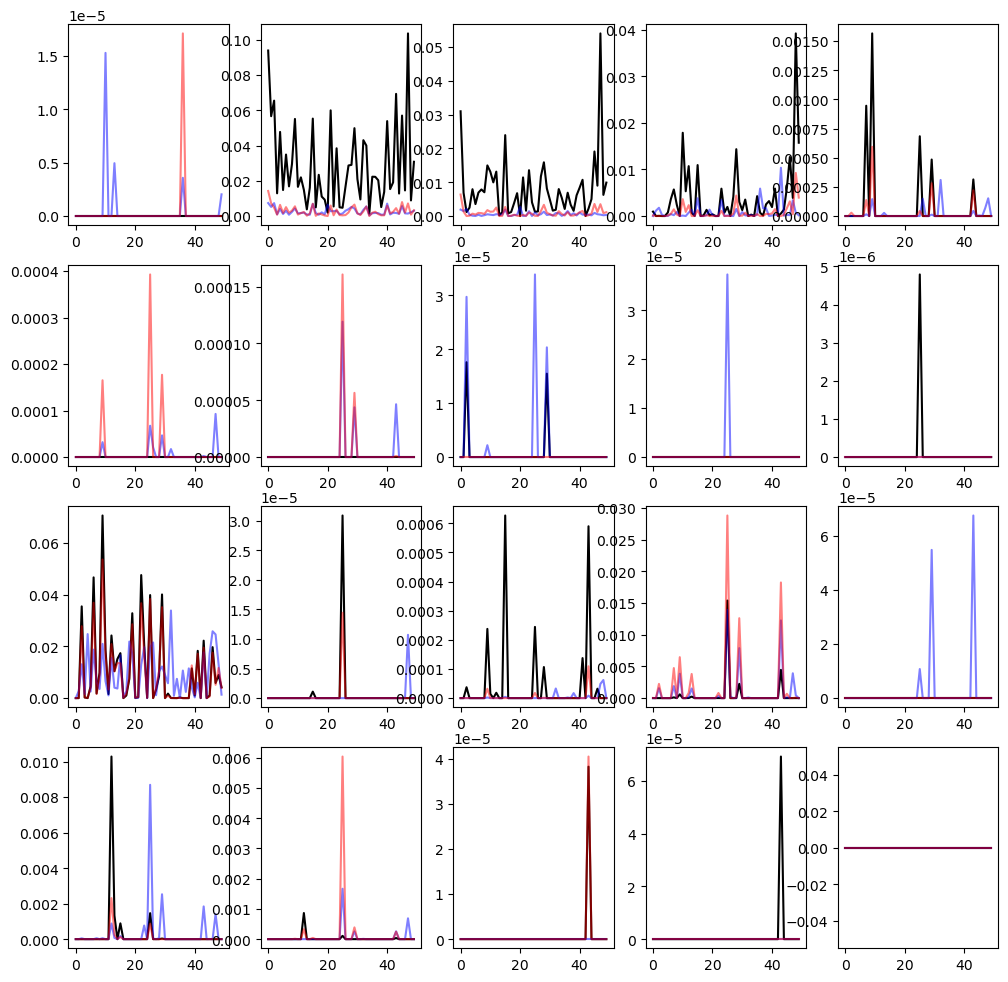

In [25]:
### Look at layer 2 as eg 

n_examples = 50 #len(dataset) # get whole dataset

layer_ix = 3 # is 4th layer with 0 ix 
gains = h5[f'attn{layer_ix}_gains'][0] # 0 is target ix 
# tgt_1_gains = gains[10]
# tgt_2_gains = gains[20]

# mean_gains = (tgt_1_gains + tgt_2_gains) / 2
unit_order = gains.argsort()

attn_out_no_cue = h5[f'attn{layer_ix}_source_unattended']
attn_out= h5[f'attn{layer_ix}_source']

top_units = unit_order[:20] 

n_units = attn_out_no_cue.shape[1]

f0_order  = source_f0s[:n_examples].argsort()
f0s_for_plot = source_f0s[:n_examples][f0_order]

f0_step = 15
# plt.plot(attn_out_no_cue[0], label='no cue')
# plt.plot(attn_out[0], label='cue')
fig, axs = plt.subplots(4, 5, figsize=(12, 12))

for i, unit_ix in enumerate(top_units):

    null_unit_response = attn_out_no_cue[:n_examples, unit_ix]
    attend_on_response = attn_out[n_examples:, unit_ix].reshape(2, -1).mean(0)
    attend_other_response = attn_out[:n_examples, unit_ix]

    ## Fit curves to each set of responses 
    null_unit_response = null_unit_response[f0_order]
    attend_on_response = attend_on_response[f0_order]
    attend_other_response = attend_other_response[f0_order]

    # coeff, var_matrix = curve_fit(gauss, f0_order, null_unit_response, p0=p0)
    # act_fit = gauss(f0_order, *coeff)

    coeffs = np.polyfit(f0s_for_plot, null_unit_response, 3)
    poly = np.poly1d(coeffs)
    act_fit = poly(f0s_for_plot)


 
    # if unit_order[0] == 0:
    axs[i//5, i%5].plot(null_unit_response, 'k', label='baseline', alpha=1)
    # axs[i//5, i%5].plot(act_fit, label='fit', alpha=1)
    axs[i//5, i%5].plot(attend_on_response, 'b', label='attend target', alpha=0.5)
    axs[i//5, i%5].plot(attend_other_response, 'r', label='attend other', alpha=0.5)
    # axs[i//5, i%5].vlines(target_f0s[0], ymin=0, ymax=10, color='k', alpha=0.5)



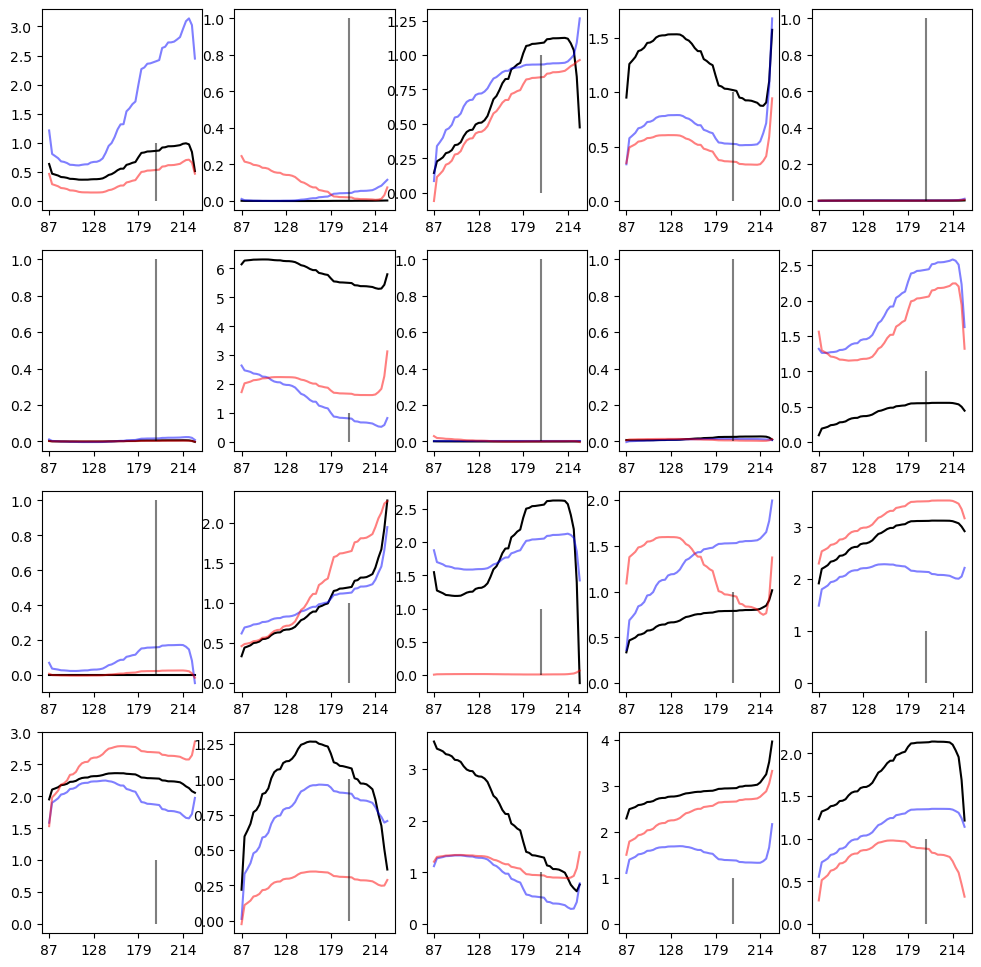

In [32]:
### Look at layer 2 as eg 

layer_ix = 5 # is 4th layer with 0 ix 

gains = h5[f'attn{layer_ix}_gains'][0] # 0 is target ix 

attn_out_no_cue = h5[f'attn{layer_ix}_source_unattended']
attn_out= h5[f'attn{layer_ix}_source']

unit_order = gains.argsort()[::-1]

top_ten = unit_order[:20] 

n_units = attn_out_no_cue.shape[1]

f0_order  = source_f0s[:n_examples].argsort()
f0s_for_plot = source_f0s[:n_examples][f0_order]

f0_step = 15
# plt.plot(attn_out_no_cue[0], label='no cue')
# plt.plot(attn_out[0], label='cue')
fig, axs = plt.subplots(4, 5, figsize=(12, 12))

for i, unit_ix in enumerate(top_ten):
    null_unit_response = attn_out_no_cue[:n_examples, unit_ix]
    attend_on_response = attn_out[:n_examples, unit_ix]
    attend_other_response = attn_out[n_examples:, unit_ix]

    ## Fit curves to each set of responses 
    null_unit_response = null_unit_response[f0_order]
    attend_on_response = attend_on_response[f0_order]
    attend_other_response = attend_other_response[f0_order]

    # coeff, var_matrix = curve_fit(gauss, f0_order, null_unit_response, p0=p0)
    # act_fit = gauss(f0_order, *coeff)

    null_fit = fit_act_data(f0s_for_plot, null_unit_response)
    attend_on_fit = fit_act_data(f0s_for_plot, attend_on_response)
    attend_other_fit = fit_act_data(f0s_for_plot, attend_other_response)



 
    # if unit_order[0] == 0:
    axs[i//5, i%5].plot(null_fit, 'k', label='baseline', alpha=1)
    # axs[i//5, i%5].plot(act_fit, label='fit', alpha=1)
    axs[i//5, i%5].plot(attend_on_fit, 'b', label='attend target', alpha=0.5)
    axs[i//5, i%5].plot(attend_other_fit, 'r', label='attend other', alpha=0.5)

    # set xticks
    axs[i//5, i%5].set_xticks(range(0, len(f0s_for_plot), f0_step))
    axs[i//5, i%5].set_xticklabels(f0s_for_plot[::f0_step].astype(int))
    vline_x_tick = np.where(f0s_for_plot == target_f0s[0])[0][0]
    # v_max - 1 
    axs[i//5, i%5].vlines(vline_x_tick, ymin=0, ymax=1, color='k', alpha=0.5)

